In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import optuna
import base64
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Reshape
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten,  Dropout, SpatialDropout2D
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Nadam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from keras.preprocessing import image
from tensorflow.keras.layers import BatchNormalization
from keras.layers import Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler
from optuna.samplers import TPESampler
from io import BytesIO


In [2]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

training_set = train_datagen.flow_from_directory(r'C:\Users\user\Desktop\python\face_expression_data\train',
                                                 target_size = (64, 64),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

Found 682 images belonging to 7 classes.


In [3]:
test_datagen = ImageDataGenerator(rescale = 1./255)

test_set = test_datagen.flow_from_directory(r'C:\Users\user\Desktop\python\face_expression_data\test',
                                            target_size = (64, 64),
                                            batch_size = 32,
                                            class_mode = 'categorical')

Found 299 images belonging to 7 classes.


In [4]:
def create_model(trial, input_shape=(64, 64, 3), num_classes=7):
    model = Sequential()

    # CNN 
    filters1 = trial.suggest_int('filters1', 32, 128, step=16)
    filters2 = trial.suggest_int('filters2', 32, 128, step=16)
    kernel_size = trial.suggest_int('kernel_size', 3, 5)
    pool_size = trial.suggest_int('pool_size', 2, 3)
    dropout_conv1 = trial.suggest_float("dropout_conv1", 0.15, 0.35)
    dropout_conv2 = trial.suggest_float("dropout_conv2", 0.15, 0.35)

    model.add(Conv2D(filters1, (kernel_size, kernel_size), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(pool_size, pool_size)))
    model.add(SpatialDropout2D(dropout_conv1))

    model.add(Conv2D(filters2, (kernel_size, kernel_size), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(pool_size, pool_size)))
    model.add(SpatialDropout2D(dropout_conv2))

    model.add(Flatten())
    model.add(Reshape((-1, filters2)))

    # RNN 
    rnn_type = trial.suggest_categorical('rnn_type', ['LSTM', 'GRU'])
    rnn_units = trial.suggest_int('rnn_units', 64, 128)
    rnn_dropout = trial.suggest_float('rnn_dropout', 0.1, 0.4)
    n_rnn_layers = trial.suggest_int('n_rnn_layers', 1, 2)

    for i in range(n_rnn_layers):
        return_sequences = i < n_rnn_layers - 1
        if rnn_type == 'LSTM':
            model.add(LSTM(rnn_units, return_sequences=return_sequences))
        else:
            model.add(GRU(rnn_units, return_sequences=return_sequences))
        model.add(Dropout(rnn_dropout))

    # ANN 
    ann_units1 = trial.suggest_int('ann_units1', 128, 256, step=32)
    ann_units2 = trial.suggest_int('ann_units2', 64, 128, step=32)
    ann_dropout1 = trial.suggest_float('ann_dropout1', 0.2, 0.4)
    ann_dropout2 = trial.suggest_float('ann_dropout2', 0.2, 0.4)

    model.add(Dense(ann_units1, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(ann_dropout1))

    model.add(Dense(ann_units2, activation='relu'))
    model.add(Dropout(ann_dropout2))

    model.add(Dense(num_classes, activation='softmax'))

    # OPTIMIZER
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])
    learning_rate = trial.suggest_float('learning_rate', 5e-5, 5e-4, log=True)

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate, clipvalue=1.0)
    else:
        optimizer = RMSprop(learning_rate=learning_rate, clipvalue=1.0)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def objective(trial):
    model = create_model(trial)
    batch_size = trial.suggest_int('batch_size', 32, 128, step=32)

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

    history = model.fit(
        training_set,
        validation_data=test_set,
        epochs=40,
        batch_size=batch_size,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    return min(history.history['val_loss'])


# OPTUNA
tpe_sampler = TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=tpe_sampler)
study.optimize(objective, n_trials=15)

best_params = study.best_trial.params
print(f"Best trial value: {study.best_trial.value}")
print(f"Best hyperparameters: {best_params}")


[I 2025-11-05 10:29:35,825] A new study created in memory with name: no-name-cccdef9a-4579-47fb-aede-76756d4834ae
C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.1935 - loss: 2.3364 - val_accuracy: 0.2241 - val_loss: 1.9405 - learning_rate: 1.6739e-04
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.2859 - loss: 2.0375 - val_accuracy: 0.3478 - val_loss: 1.9170 - learning_rate: 1.6739e-04
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.3431 - loss: 1.9074 - val_accuracy: 0.2609 - val_loss: 1.9003 - learning_rate: 1.6739e-04
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.3739 - loss: 1.8167 - val_accuracy: 0.1438 - val_loss: 1.9117 - learning_rate: 1.6739e-04
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.4003 - loss: 1.6526 - val_accuracy: 0.1438 - val_loss: 1.9333 - learning_rate: 1.6739e-04
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.4584 - loss: 1.5702
Epoch 6: ReduceLROnPlateau reducing learning rate to 8.369440911337733e-05.
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.460

[I 2025-11-05 10:30:10,679] Trial 0 finished with value: 1.9003299474716187 and parameters: {'filters1': 64, 'filters2': 128, 'kernel_size': 5, 'pool_size': 3, 'dropout_conv1': 0.18120372808848728, 'dropout_conv2': 0.1811989040672405, 'rnn_type': 'GRU', 'rnn_units': 103, 'rnn_dropout': 0.3124217733388137, 'n_rnn_layers': 1, 'ann_units1': 256, 'ann_units2': 128, 'ann_dropout1': 0.24246782213565524, 'ann_dropout2': 0.23636499344142015, 'optimizer': 'rmsprop', 'learning_rate': 0.0001673888154257967, 'batch_size': 64}. Best is trial 0 with value: 1.9003299474716187.


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.1774 - loss: 2.6711 - val_accuracy: 0.1873 - val_loss: 1.9425 - learning_rate: 1.0083e-04
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.1686 - loss: 2.6278 - val_accuracy: 0.1271 - val_loss: 1.9466 - learning_rate: 1.0083e-04
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.1789 - loss: 2.5429 - val_accuracy: 0.1137 - val_loss: 1.9463 - learning_rate: 1.0083e-04
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.1892 - loss: 2.5678
Epoch 4: ReduceLROnPlateau reducing learning rate to 5.0414302677381784e-05.
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.1848 - loss: 2.5122 - val_accuracy: 0.1137 - val_loss: 1.9451 - learning_rate: 1.0083e-04
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.1935 - loss: 2.4756 - val_accuracy: 0.0803 - val_loss: 1.9468 - learning_rate: 5.0414e-05
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step - accuracy: 0.18

[I 2025-11-05 10:30:47,947] Trial 1 finished with value: 1.9424928426742554 and parameters: {'filters1': 64, 'filters2': 96, 'kernel_size': 3, 'pool_size': 2, 'dropout_conv1': 0.22327236865873834, 'dropout_conv2': 0.24121399684340716, 'rnn_type': 'LSTM', 'rnn_units': 97, 'rnn_dropout': 0.2777243706586128, 'n_rnn_layers': 1, 'ann_units1': 224, 'ann_units2': 64, 'ann_dropout1': 0.2130103185970559, 'ann_dropout2': 0.3897771074506667, 'optimizer': 'adam', 'learning_rate': 0.00010082860845904296, 'batch_size': 32}. Best is trial 0 with value: 1.9003299474716187.


...

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.1202 - loss: 3.0804 - val_accuracy: 0.2709 - val_loss: 1.9336 - learning_rate: 2.6921e-04
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.1364 - loss: 2.7473 - val_accuracy: 0.2508 - val_loss: 1.9288 - learning_rate: 2.6921e-04
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.1716 - loss: 2.5907 - val_accuracy: 0.1605 - val_loss: 1.9250 - learning_rate: 2.6921e-04
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.1716 - loss: 2.5124 - val_accuracy: 0.1371 - val_loss: 1.9260 - learning_rate: 2.6921e-04
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.2361 - loss: 2.2613 - val_accuracy: 0.1538 - val_loss: 1.9260 - learning_rate: 2.6921e-04
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.2478 - loss: 2.2158 - val_accuracy: 0.2140 - val_loss: 1.9245 - learning_rate: 2.6921e-04
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 

[I 2025-11-05 10:50:24,948] Trial 13 finished with value: 0.8244109153747559 and parameters: {'filters1': 48, 'filters2': 48, 'kernel_size': 4, 'pool_size': 3, 'dropout_conv1': 0.2466417268988823, 'dropout_conv2': 0.3172850320409873, 'rnn_type': 'GRU', 'rnn_units': 111, 'rnn_dropout': 0.3426365629431202, 'n_rnn_layers': 2, 'ann_units1': 192, 'ann_units2': 64, 'ann_dropout1': 0.3199281688839248, 'ann_dropout2': 0.3217916560799209, 'optimizer': 'adam', 'learning_rate': 0.0002692050138327883, 'batch_size': 64}. Best is trial 13 with value: 0.8244109153747559.


Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 314ms/step - accuracy: 0.1158 - loss: 2.9104 - val_accuracy: 0.2107 - val_loss: 1.9375 - learning_rate: 2.6483e-04
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.1598 - loss: 2.5980 - val_accuracy: 0.2508 - val_loss: 1.9340 - learning_rate: 2.6483e-04
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 292ms/step - accuracy: 0.1701 - loss: 2.5665 - val_accuracy: 0.1706 - val_loss: 1.9309 - learning_rate: 2.6483e-04
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.1921 - loss: 2.4553 - val_accuracy: 0.2007 - val_loss: 1.9372 - learning_rate: 2.6483e-04
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 302ms/step - accuracy: 0.2522 - loss: 2.3019 - val_accuracy: 0.1839 - val_loss: 1.9488 - learning_rate: 2.6483e-04
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.2595 - loss: 2.1872
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00013241452688816935.
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 295ms/step - accuracy: 0.2

[I 2025-11-05 10:51:21,265] Trial 14 finished with value: 1.9309433698654175 and parameters: {'filters1': 48, 'filters2': 96, 'kernel_size': 4, 'pool_size': 2, 'dropout_conv1': 0.22941615243811023, 'dropout_conv2': 0.3430465035758389, 'rnn_type': 'GRU', 'rnn_units': 112, 'rnn_dropout': 0.3313783699020297, 'n_rnn_layers': 2, 'ann_units1': 224, 'ann_units2': 64, 'ann_dropout1': 0.31730371564110577, 'ann_dropout2': 0.33629739922824486, 'optimizer': 'adam', 'learning_rate': 0.0002648290454765593, 'batch_size': 64}. Best is trial 13 with value: 0.8244109153747559.


Best trial value: 0.8244109153747559
Best hyperparameters: {'filters1': 48, 'filters2': 48, 'kernel_size': 4, 'pool_size': 3, 'dropout_conv1': 0.2466417268988823, 'dropout_conv2': 0.3172850320409873, 'rnn_type': 'GRU', 'rnn_units': 111, 'rnn_dropout': 0.3426365629431202, 'n_rnn_layers': 2, 'ann_units1': 192, 'ann_units2': 64, 'ann_dropout1': 0.3199281688839248, 'ann_dropout2': 0.3217916560799209, 'optimizer': 'adam', 'learning_rate': 0.0002692050138327883, 'batch_size': 64}


In [5]:
best_params = study.best_trial.params

best_params

{'filters1': 48,
 'filters2': 48,
 'kernel_size': 4,
 'pool_size': 3,
 'dropout_conv1': 0.2466417268988823,
 'dropout_conv2': 0.3172850320409873,
 'rnn_type': 'GRU',
 'rnn_units': 111,
 'rnn_dropout': 0.3426365629431202,
 'n_rnn_layers': 2,
 'ann_units1': 192,
 'ann_units2': 64,
 'ann_dropout1': 0.3199281688839248,
 'ann_dropout2': 0.3217916560799209,
 'optimizer': 'adam',
 'learning_rate': 0.0002692050138327883,
 'batch_size': 64}

In [6]:
def create_final_model(best_params, input_shape=(64, 64, 3), num_classes=7):
    model = Sequential()

    model.add(Conv2D(best_params['filters1'], (best_params['kernel_size'], best_params['kernel_size']), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(best_params['pool_size'], best_params['pool_size'])))
    model.add(SpatialDropout2D(best_params['dropout_conv1']))

    model.add(Conv2D(best_params['filters2'], (best_params['kernel_size'], best_params['kernel_size']), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPool2D(pool_size=(best_params['pool_size'], best_params['pool_size'])))
    model.add(SpatialDropout2D(best_params['dropout_conv2']))

    model.add(Flatten())
    model.add(Reshape((-1, best_params['filters2'])))

    for i in range(best_params['n_rnn_layers']):
        return_sequences = i < best_params['n_rnn_layers'] - 1
        if best_params['rnn_type'] == 'LSTM':
            model.add(LSTM(best_params['rnn_units'], return_sequences=return_sequences))
        else:
            model.add(GRU(best_params['rnn_units'], return_sequences=return_sequences))
        model.add(Dropout(best_params['rnn_dropout']))

    model.add(Dense(best_params['ann_units1'], activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(best_params['ann_dropout1']))

    model.add(Dense(best_params['ann_units2'], activation='relu'))
    model.add(Dropout(best_params['ann_dropout2']))

    model.add(Dense(num_classes, activation='softmax'))

    if best_params['optimizer'] == 'adam':
        optimizer = Adam(learning_rate=best_params['learning_rate'], clipvalue=1.0)
    else:
        optimizer = RMSprop(learning_rate=best_params['learning_rate'], clipvalue=1.0)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


In [7]:
final_model = create_final_model(best_params)
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

history = final_model.fit(
    training_set,
    validation_data=test_set,
    epochs=50,
    batch_size=best_params.get('batch_size', 64),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step - accuracy: 0.1422 - loss: 2.9235 - val_accuracy: 0.2475 - val_loss: 1.9358 - learning_rate: 2.6921e-04
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.1378 - loss: 2.7550 - val_accuracy: 0.1806 - val_loss: 1.9209 - learning_rate: 2.6921e-04
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.1657 - loss: 2.5198 - val_accuracy: 0.1906 - val_loss: 1.9084 - learning_rate: 2.6921e-04
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.1979 - loss: 2.4217 - val_accuracy: 0.2375 - val_loss: 1.8992 - learning_rate: 2.6921e-04
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.2258 - loss: 2.2180 - val_accuracy: 0.2308 - val_loss: 1.8863 - learning_rate: 2.6921e-04
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.2478 - loss: 2.1792 - val_accuracy: 0.3712 - val_loss: 1.8766 - learning_rate: 2.6921e-04
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 

In [8]:
train_loss, train_accuracy = final_model.evaluate(training_set)
test_loss, test_accuracy = final_model.evaluate(test_set)

print(f"\nTrain Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6818 - loss: 0.8835
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7057 - loss: 0.7928

Train Loss: 0.8835
Train Accuracy: 0.6818
Test Loss: 0.7928
Test Accuracy: 0.7057


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


,Image,Prediction
0,,happy
1,,happy
2,,happy
3,,happy
4,,happy
5,,happy
6,,happy
7,,happy
8,,happy
9,,disgust

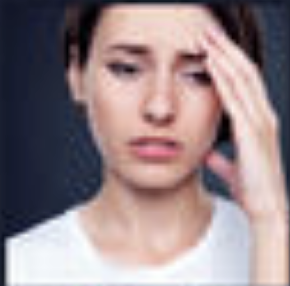
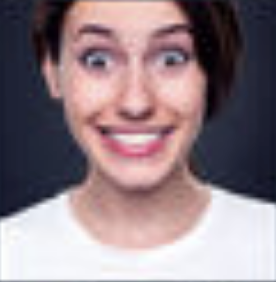
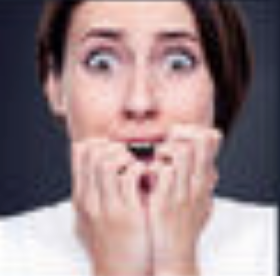
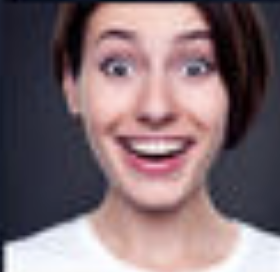
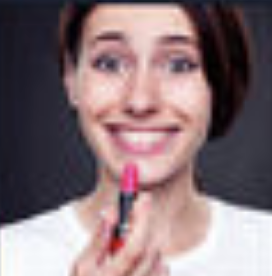
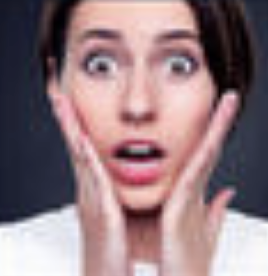
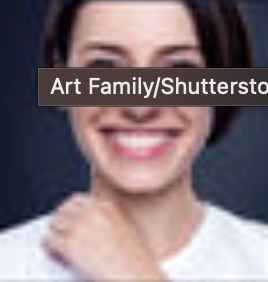
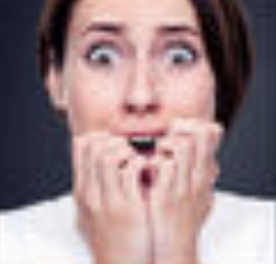
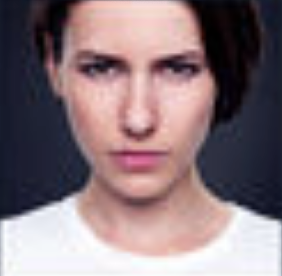
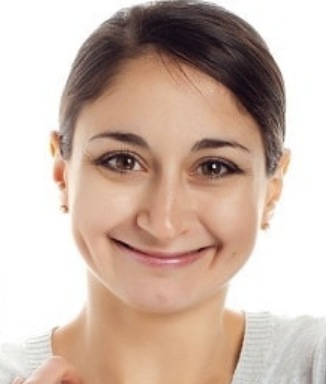
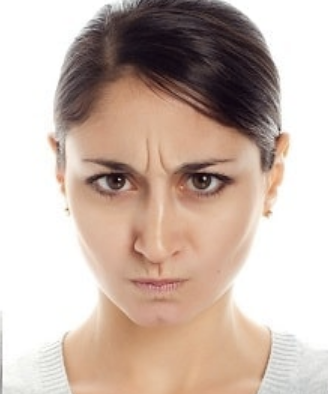
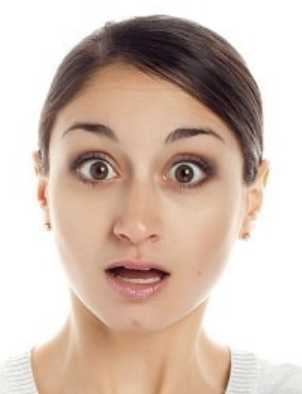
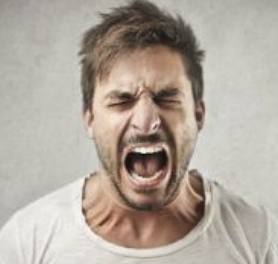
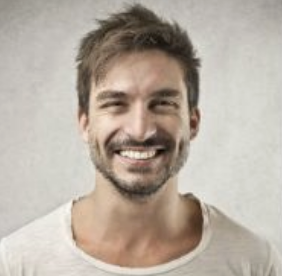
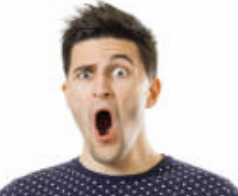
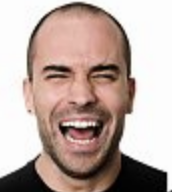
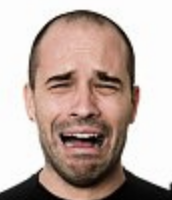

In [9]:
def img_to_displayable_format(img_path):
    with open(img_path, "rb") as img_file:
        encoded_img = base64.b64encode(img_file.read()).decode('utf-8')
    return f'<img src="data:image/jpeg;base64,{encoded_img}" width="64" height="64"/>'

folder_path = r'C:\Users\user\Desktop\python\face_expression_data\single_prediction'

results = []

class_names = {v: k for k, v in training_set.class_indices.items()}

for filename in os.listdir(folder_path):
    if filename.endswith(('.png', '.jpg', '.jpeg', '.webp')):
        
        img_path = os.path.join(folder_path, filename)
        test_image = image.load_img(img_path, target_size=(64, 64))
        test_image_array = image.img_to_array(test_image)
        test_image_array = np.expand_dims(test_image_array, axis=0)

        result = final_model.predict(test_image_array / 255.0)

        predicted_class_index = np.argmax(result)

        prediction = class_names[predicted_class_index]

        img_display = img_to_displayable_format(img_path)
        results.append({'Image': img_display, 'Prediction': prediction})

df_results = pd.DataFrame(results)

from IPython.display import display, HTML
display(HTML(df_results.to_html(escape=False)))